In [1]:
from google.colab import files

uploaded = files.upload()

Saving Telco_customer_churn.xlsx to Telco_customer_churn.xlsx


In [3]:
!pip install -q pandas numpy matplotlib scikit-learn joblib openpyxl

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import sklearn

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    classification_report,
    ConfusionMatrixDisplay
)

print("Scikit-learn version:", sklearn.__version__)

Scikit-learn version: 1.6.1


In [5]:
df = pd.read_excel(
    "Telco_customer_churn.xlsx",
    engine="openpyxl"
)

df.head()

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


In [6]:
print("Dataset shape:", df.shape)
print("\nColumns:")
print(df.columns.tolist())

Dataset shape: (7043, 33)

Columns:
['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason']


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

In [8]:
print(df.isnull().sum())

CustomerID              0
Count                   0
Country                 0
State                   0
City                    0
Zip Code                0
Lat Long                0
Latitude                0
Longitude               0
Gender                  0
Senior Citizen          0
Partner                 0
Dependents              0
Tenure Months           0
Phone Service           0
Multiple Lines          0
Internet Service        0
Online Security         0
Online Backup           0
Device Protection       0
Tech Support            0
Streaming TV            0
Streaming Movies        0
Contract                0
Paperless Billing       0
Payment Method          0
Monthly Charges         0
Total Charges           0
Churn Label             0
Churn Value             0
Churn Score             0
CLTV                    0
Churn Reason         5174
dtype: int64


In [9]:
print(df["Churn Value"].value_counts(dropna=False))

Churn Value
0    5174
1    1869
Name: count, dtype: int64


In [10]:
df["Total Charges"] = pd.to_numeric(
    df["Total Charges"],
    errors="coerce"
)

In [11]:
print(
    "Missing Total Charges:",
    df["Total Charges"].isnull().sum()
)

Missing Total Charges: 11


In [12]:
print(df["Churn Value"].head())
print(df["Churn Value"].dtype)
print(df["Churn Value"].value_counts(dropna=False))

0    1
1    1
2    1
3    1
4    1
Name: Churn Value, dtype: int64
int64
Churn Value
0    5174
1    1869
Name: count, dtype: int64


Churn Value
0    5174
1    1869
Name: count, dtype: int64


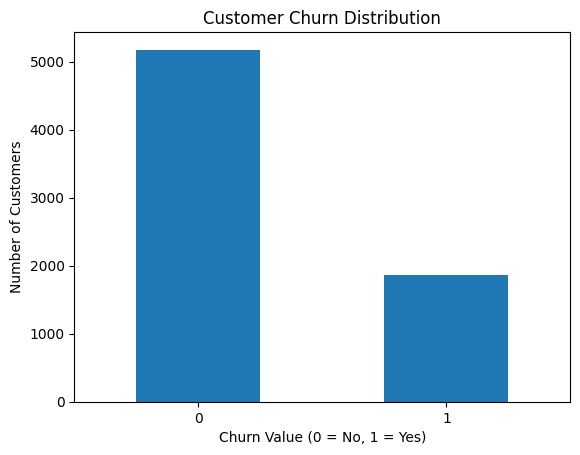

In [13]:
churn_counts = (
    df["Churn Value"]
    .value_counts()
    .sort_index()
)

print(churn_counts)

churn_counts.plot(
    kind="bar",
    title="Customer Churn Distribution"
)

plt.xlabel("Churn Value (0 = No, 1 = Yes)")
plt.ylabel("Number of Customers")
plt.xticks(rotation=0)
plt.show()

In [14]:
y = df["Churn Value"].astype(int)

In [15]:
columns_to_drop = [
    "CustomerID",
    "Count",
    "Country",
    "State",
    "City",
    "Zip Code",
    "Lat Long",
    "Latitude",
    "Longitude",
    "Churn Label",
    "Churn Value",
    "Churn Score",
    "CLTV",
    "Churn Reason"
]

In [16]:
X = df.drop(
    columns=[
        column
        for column in columns_to_drop
        if column in df.columns
    ]
)

In [17]:
print("X shape:", X.shape)
print("y shape:", y.shape)

print("\nFinal feature columns:")
print(X.columns.tolist())

X shape: (7043, 19)
y shape: (7043,)

Final feature columns:
['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges']


In [18]:
for column in X.columns:
    print(f"\n{column}:")
    print(X[column].dropna().unique()[:10])


Gender:
['Male' 'Female']

Senior Citizen:
['No' 'Yes']

Partner:
['No' 'Yes']

Dependents:
['No' 'Yes']

Tenure Months:
[ 2  8 28 49 10  1 47 17  5 34]

Phone Service:
['Yes' 'No']

Multiple Lines:
['No' 'Yes' 'No phone service']

Internet Service:
['DSL' 'Fiber optic' 'No']

Online Security:
['Yes' 'No' 'No internet service']

Online Backup:
['Yes' 'No' 'No internet service']

Device Protection:
['No' 'Yes' 'No internet service']

Tech Support:
['No' 'Yes' 'No internet service']

Streaming TV:
['No' 'Yes' 'No internet service']

Streaming Movies:
['No' 'Yes' 'No internet service']

Contract:
['Month-to-month' 'Two year' 'One year']

Paperless Billing:
['Yes' 'No']

Payment Method:
['Mailed check' 'Electronic check' 'Bank transfer (automatic)'
 'Credit card (automatic)']

Monthly Charges:
[ 53.85  70.7   99.65 104.8  103.7   55.2   39.65  20.15  99.35  30.2 ]

Total Charges:
[ 108.15  151.65  820.5  3046.05 5036.3   528.35   39.65   20.15 4749.15
   30.2 ]


In [19]:
print(df["Senior Citizen"].unique())

['No' 'Yes']


In [20]:
numerical_columns = X.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
).columns.tolist()

categorical_columns = X.select_dtypes(
    include=["object", "category"]
).columns.tolist()

print("Numerical columns:")
print(numerical_columns)

print("\nCategorical columns:")
print(categorical_columns)

Numerical columns:
['Tenure Months', 'Monthly Charges', 'Total Charges']

Categorical columns:
['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method']


In [21]:
numerical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="median")
        ),
        (
            "scaler",
            StandardScaler()
        )
    ]
)

In [22]:
categorical_pipeline = Pipeline(
    steps=[
        (
            "imputer",
            SimpleImputer(strategy="most_frequent")
        ),
        (
            "encoder",
            OneHotEncoder(
                handle_unknown="ignore"
            )
        )
    ]
)

In [23]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "numerical",
            numerical_pipeline,
            numerical_columns
        ),
        (
            "categorical",
            categorical_pipeline,
            categorical_columns
        )
    ]
)

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training rows:", X_train.shape[0])
print("Testing rows:", X_test.shape[0])

Training rows: 5634
Testing rows: 1409


In [25]:
logistic_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            LogisticRegression(
                max_iter=1000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

In [26]:
logistic_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Tenure Months',
                                                   'Monthly Charges',
                                                   'Total Charges']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Senior Citizen',
                                                   'Partner', 'Dependents',
                                                   'Phone Service',
                                                   'Multiple Lines',
                                                   'Internet Service',
                                                   'Online Security',
                                                   'Online Backup',
                                                   'Device Protection',
                                                   'Tech Support',
                                                   'Streaming TV',
                                                   'Streaming Movies',
                                                   'Contract',
                                                   'Paperless Billing',
                                                   'Payment Method'])])),
                ('model',
                 LogisticRegression(class_weight='balanced', max_iter=1000,
                                    random_state=42))])

In [27]:
random_forest_pipeline = Pipeline(
    steps=[
        (
            "preprocessor",
            preprocessor
        ),
        (
            "model",
            RandomForestClassifier(
                n_estimators=100,
                random_state=42,
                class_weight="balanced",
                n_jobs=-1
            )
        )
    ]
)

In [28]:
random_forest_pipeline.fit(
    X_train,
    y_train
)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('numerical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('scaler',
                                                                   StandardScaler())]),
                                                  ['Tenure Months',
                                                   'Monthly Charges',
                                                   'Total Charges']),
                                                 ('categorical',
                                                  Pipeline(steps=[('imputer',
                                                                   SimpleImputer(strategy='most_frequent')),
                                                                  ('encoder',
                                                                   OneHotEncoder(handle_unknown='ignore'))]),
                                                  ['Gender', 'Senior Citizen',
                                                   'Partner', 'Dependents',
                                                   'Phone Service',
                                                   'Multiple Lines',
                                                   'Internet Service',
                                                   'Online Security',
                                                   'Online Backup',
                                                   'Device Protection',
                                                   'Tech Support',
                                                   'Streaming TV',
                                                   'Streaming Movies',
                                                   'Contract',
                                                   'Paperless Billing',
                                                   'Payment Method'])])),
                ('model',
                 RandomForestClassifier(class_weight='balanced', n_jobs=-1,
                                        random_state=42))])

In [29]:
def evaluate_model(model, X_test, y_test, model_name):
    predictions = model.predict(X_test)
    probabilities = model.predict_proba(X_test)[:, 1]

    results = {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, predictions),
        "Precision": precision_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "Recall": recall_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "F1 Score": f1_score(
            y_test,
            predictions,
            zero_division=0
        ),
        "ROC-AUC": roc_auc_score(
            y_test,
            probabilities
        )
    }

    print(f"\n{model_name}")
    print("-" * 60)

    for metric, value in results.items():
        if metric != "Model":
            print(f"{metric}: {value:.4f}")

    print("\nClassification Report:")
    print(
        classification_report(
            y_test,
            predictions,
            zero_division=0
        )
    )

    ConfusionMatrixDisplay.from_predictions(
        y_test,
        predictions
    )

    plt.title(f"{model_name} Confusion Matrix")
    plt.show()

    return results


Logistic Regression
------------------------------------------------------------
Accuracy: 0.7431
Precision: 0.5105
Recall: 0.7807
F1 Score: 0.6173
ROC-AUC: 0.8488

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.73      0.81      1035
           1       0.51      0.78      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409



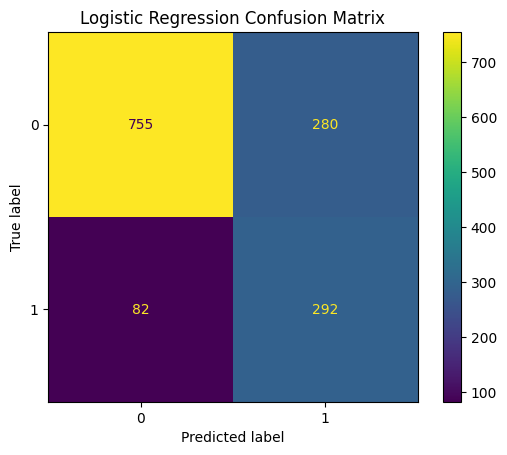

In [30]:
logistic_results = evaluate_model(
    logistic_pipeline,
    X_test,
    y_test,
    "Logistic Regression"
)


Random Forest
------------------------------------------------------------
Accuracy: 0.7906
Precision: 0.6357
Recall: 0.4947
F1 Score: 0.5564
ROC-AUC: 0.8322

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.49      0.56       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



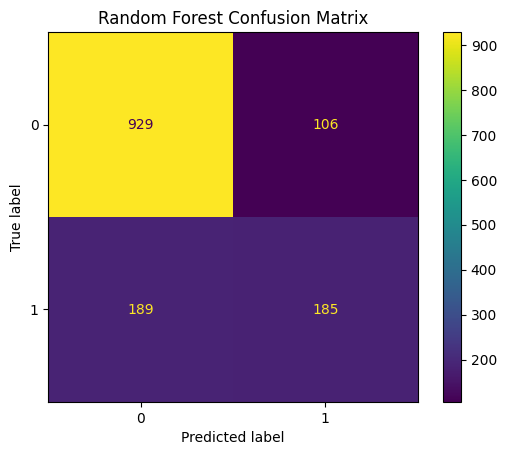

In [31]:
random_forest_results = evaluate_model(
    random_forest_pipeline,
    X_test,
    y_test,
    "Random Forest"
)

In [32]:
parameter_grid = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2]
}

In [33]:
grid_search = GridSearchCV(
    estimator=random_forest_pipeline,
    param_grid=parameter_grid,
    scoring="f1",
    cv=5,
    n_jobs=-1,
    verbose=2
)

In [34]:
grid_search.fit(
    X_train,
    y_train
)

Fitting 5 folds for each of 24 candidates, totalling 120 fits


GridSearchCV(cv=5,
             estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('numerical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('scaler',
                                                                                          StandardScaler())]),
                                                                         ['Tenure '
                                                                          'Months',
                                                                          'Monthly '
                                                                          'Charges',
                                                                          'Total '
                                                                          'Charges']),
                                                                        ('categorical',
                                                                         Pipeline(steps=[('imputer',
                                                                                          SimpleImputer(strategy='most_frequent')),
                                                                                         ('encoder',
                                                                                          OneH...
                                                                          'Streaming '
                                                                          'TV',
                                                                          'Streaming '
                                                                          'Movies',
                                                                          'Contract',
                                                                          'Paperless '
                                                                          'Billing',
                                                                          'Payment '
                                                                          'Method'])])),
                                       ('model',
                                        RandomForestClassifier(class_weight='balanced',
                                                               n_jobs=-1,
                                                               random_state=42))]),
             n_jobs=-1,
             param_grid={'model__max_depth': [None, 10, 20],
                         'model__min_samples_leaf': [1, 2],
                         'model__min_samples_split': [2, 5],
                         'model__n_estimators': [100, 200]},
             scoring='f1', verbose=2)

In [35]:
print("Best parameters:")
print(grid_search.best_params_)

print("\nBest cross-validation F1 score:")
print(grid_search.best_score_)

Best parameters:
{'model__max_depth': 10, 'model__min_samples_leaf': 2, 'model__min_samples_split': 2, 'model__n_estimators': 200}

Best cross-validation F1 score:
0.649670795453751


In [36]:
tuned_random_forest = grid_search.best_estimator_


Tuned Random Forest
------------------------------------------------------------
Accuracy: 0.7700
Precision: 0.5500
Recall: 0.7353
F1 Score: 0.6293
ROC-AUC: 0.8501

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.78      0.83      1035
           1       0.55      0.74      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.78      1409



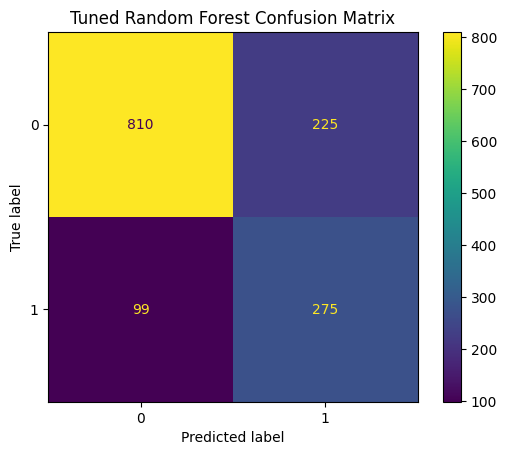

In [37]:
tuned_results = evaluate_model(
    tuned_random_forest,
    X_test,
    y_test,
    "Tuned Random Forest"
)

In [38]:
results_df = pd.DataFrame([
    logistic_results,
    random_forest_results,
    tuned_results
])

results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.743080,0.510490,0.780749,0.617336,0.848756
1,Random Forest,0.790632,0.635739,0.494652,0.556391,0.832246
2,Tuned Random Forest,0.770050,0.550000,0.735294,0.629291,0.850115


In [39]:
results_df.sort_values(
    by="F1 Score",
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
2,Tuned Random Forest,0.770050,0.550000,0.735294,0.629291,0.850115
0,Logistic Regression,0.743080,0.510490,0.780749,0.617336,0.848756
1,Random Forest,0.790632,0.635739,0.494652,0.556391,0.832246


In [40]:
model_candidates = {
    "Logistic Regression": logistic_pipeline,
    "Random Forest": random_forest_pipeline,
    "Tuned Random Forest": tuned_random_forest
}

best_model_name = results_df.sort_values(
    by="F1 Score",
    ascending=False
).iloc[0]["Model"]

best_churn_model = model_candidates[
    best_model_name
]

print("Selected final model:", best_model_name)

Selected final model: Tuned Random Forest


In [41]:
print("Model input columns:")
print(X.columns.tolist())

Model input columns:
['Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges']


In [42]:
assert "CLTV" not in X.columns
print("CLTV successfully removed.")

CLTV successfully removed.


In [43]:
joblib.dump(
    best_churn_model,
    "churn_pipeline.joblib"
)

print("Model saved successfully.")

Model saved successfully.


In [44]:
loaded_model = joblib.load(
    "churn_pipeline.joblib"
)

In [45]:
sample_rows = X_test.iloc[:5]

sample_predictions = loaded_model.predict(
    sample_rows
)

sample_probabilities = loaded_model.predict_proba(
    sample_rows
)[:, 1]

print("Predictions:")
print(sample_predictions)

print("\nProbabilities:")
print(sample_probabilities)

Predictions:
[0 1 0 1 0]

Probabilities:
[0.06366634 0.83830295 0.14475863 0.54910267 0.0452323 ]


In [46]:
import json

model_information = {
    "selected_model": best_model_name,
    "scikit_learn_version": sklearn.__version__,
    "feature_columns": X.columns.tolist(),
    "numerical_columns": numerical_columns,
    "categorical_columns": categorical_columns,
    "best_parameters": (
        grid_search.best_params_
        if best_model_name == "Tuned Random Forest"
        else None
    )
}

with open(
    "model_info.json",
    "w",
    encoding="utf-8"
) as file:
    json.dump(
        model_information,
        file,
        indent=4
    )

In [47]:
from google.colab import files

files.download("churn_pipeline.joblib")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [48]:
files.download("model_info.json")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>